# Chapter 4 - Trees & Graphs

## Trees
https://stackoverflow.com/questions/34012886/print-binary-tree-level-by-level-in-python

In [52]:
class TreeNode:

    def __init__(self, key):
        self.key = key
        self.right = None
        self.left = None

    def insert(self, key):
        if self.key == key:
            return
        elif self.key < key:
            if self.right is None:
                self.right = BstNode(key)
            else:
                self.right.insert(key)
        else: # self.key > key
            if self.left is None:
                self.left = BstNode(key)
            else:
                self.left.insert(key)

In [53]:
import random
from trees_graphs import TreeNode
from trees_graphs import build_min_heap
#from trees_graphs import MinHeap
%reload_ext autoreload
%autoreload 2

def binary_search_tree(n, min=0, max=100):
    b = TreeNode(random.randint(min, max))
    for _ in range(n-1):
        b.insert(random.randint(min, max))
    return b

def binary_tree(n, min=0, max=100):
    root = TreeNode(random.randint(min, max))
    node = root
    for _ in range(n-1):
        insert_left = random.randint(0, 1) == 0
        value = random.randint(min, max)
        if insert_left: 
            if node.left != None: node = node.left
            node.left = BstNode(value)
            if node.right != None: node = node.left
        else:
            if node.right != None: node = node.right
            node.right = BstNode(value)
            if node.left != None: node = node.right
    return root


### Traversal

In [54]:
# In-order traversal means to "visit" (often, print) the left branch, then the current node, and finally, the right branch.
def in_order_traversal(node, results=[]):
    #if len(results) == 0: results.append(node.key)
    if node != None:
        in_order_traversal(node.left, results)
        results.append(node.key)
        in_order_traversal(node.right, results)

# Pre-order traversal visits the current node before its child nodes (hence the name "pre-order").
def pre_order_traversal(node, results=[]):
    if node != None:
        results.append(node.key)
        pre_order_traversal(node.left, results)
        pre_order_traversal(node.right, results)

# Post-order traversal visits the current node after its child nodes (hence the name "post-order").
def post_order_traversal(node, results=[]):
    if node != None:
        post_order_traversal(node.left, results)
        post_order_traversal(node.right, results)
        results.append(node.key)

In [76]:
root = binary_search_tree(8)
root.display()
print()
arr = []
in_order_traversal(root, arr)
print("in-order:\t",arr)
arr = []
pre_order_traversal(root, arr)
print("pre-order:\t",arr)
arr = []
post_order_traversal(root, arr)
print("post-order:\t",arr)

 ___41___     
/        \    
1       81_   
 \     /   \  
 4_   52  85_ 
   \         \
  32        93

in-order:	 [1, 4, 32, 41, 52, 81, 85, 93]
pre-order:	 [41, 1, 4, 32, 81, 52, 85, 93]
post-order:	 [32, 4, 1, 52, 93, 85, 81, 41]


### Balanced BST

In [56]:
def balanced_bst(node):    
    arr = []
    in_order_traversal(root,arr)
    return arr_to_balanced_bst(arr)

def arr_to_balanced_bst(arr):
        if not arr: return None

        # get middle node
        mid = len(arr) // 2
        root = TreeNode(arr[mid])

        # recursively get left and right half of tree
        root.left = arr_to_balanced_bst(arr[0:mid])
        root.right = arr_to_balanced_bst(arr[mid+1:])

        return root

In [57]:
# creat bst
root = binary_search_tree(8)

# display tree
print('binary search tree')
root.display()
arr = []
in_order_traversal(root, arr)
print("in-order:\t",arr)


# create balanced bst
bal = balanced_bst(root)
print()
print('balanced binary search tree')
bal.display()

arr = []
in_order_traversal(root, arr)
print("in-order:\t",arr)

binary search tree
24___         
     \        
    38_______ 
   /         \
  35        97
           /  
          95  
         /    
        92    
       /      
      57      
in-order:	 [24, 35, 38, 57, 92, 95, 97]

balanced binary search tree
    __57___   
   /       \  
  35_     95_ 
 /   \   /   \
24  38  92  97
in-order:	 [24, 35, 38, 57, 92, 95, 97]


## Heaps
https://jaykalia07.medium.com/heaps-the-cutest-little-data-structure-ever-invented-a1d0010cca84

<img src="https://miro.medium.com/max/2880/1*JwKtVDKjG1Bn9EIbr5K-MQ.png" width=33% />

 - It’s parent is at the floor (i)/2 index.
 - It’s left child is at 2 * i index.
 - It’s right child is at 2 *i + 1 index.

https://jaykalia07.medium.com/heaps-the-cutest-little-data-structure-ever-invented-a1d0010cca84

https://www.askpython.com/python/examples/min-heap



In [58]:
class MinHeap:
    def __init__(self, arr = None, maxsize=10):
        
        self.cursize = 0
        self.maxsize = maxsize
        self.MIN = -999999999
        self.MAX = 999999999
        self.arr = [None]*self.maxsize # 1-based array
        self.arr.insert(0, None)

        if arr != None: self.set_arr(arr)

    def __str__(self):
        return str(self.arr)
        
    def set_arr(self, arr):
        # increase maxsize if input > maxsize
        if len(arr) > self.maxsize: return 
        # empty arr
        self.arr = [None]*len(self.arr)
        # set elements starting at 1
        for i in range(0, len(arr)):
            self.arr[i+1] = arr[i]
        self.cursize = len(arr)
        self.minheap()

    def swapnodes(self, i, j):
        self.arr[i], self.arr[j] = self.arr[j], self.arr[i]

    def minheap(self):
        for i in range(self.cursize//2, 0, -1):
            self.heapify(i)
        
    def heapify(self, i):
        # get index for childrend (1-based)
        ileft = 2*i
        iright = 2*i + 1

        # get left and right values (set to MAX if they don't exist)
        left = self.MAX
        right = self.MAX
        if ileft <= self.maxsize and self.arr[ileft] != None: left = self.arr[ileft]
        if iright <= self.maxsize and self.arr[iright] != None: right = self.arr[iright]
        leaf = ileft > self.cursize and iright > self.cursize 
        
        # if not leaf and value greater than children's
        if not leaf and i <= self.cursize and self.arr[i] > min(left, right):
            # swap with left if left < right
            if left < right:
                self.swapnodes(i, ileft)
                self.heapify(ileft)
            # else swap with right
            else:
                self.swapnodes(i, iright)
                self.heapify(iright)

    def insert(self, key):
        # return if size limit reached
        if self.cursize + 1 > self.maxsize: return
        # increment size
        self.cursize += 2
        # add element to far right
        self.arr[self.cursize] = key
        # swap nodes up the tree until current >= parent
        icurrent = self.cursize
        iparent = icurrent//2
        while self.arr[icurrent] < self.arr[iparent]:
            self.swapnodes(icurrent, iparent)
            icurrent = iparent
            iparent = icurrent//2

    def extractmin(self):
        # return if no elements in tree
        if self.cursize < 1: return 
        # get root value
        root = self.arr[1]
        # remove first element and set cursize
        arr = self.arr[2:]
        # re-heapify
        self.set_arr(arr=arr)
        return root


In [59]:
arr = [10,15,7,9,4,13]

print('balanced bst')
bst = arr_to_balanced_bst(arr)
bst.display()
print()
print('min heap')
h = MinHeap(arr=arr)
hnode = build_min_heap(h.arr)
hnode.display()
print()
print('insert 6 and 12')
h.insert(6)
h.insert(12)
hnode = build_min_heap(h.arr)
hnode.display()
print()
print('extract min:', h.extractmin())
hnode = build_min_heap(h.arr)
hnode.display()

balanced bst
    _9__ 
   /    \
  15   13
 /  \ /  
10  7 4  

min heap
   __4__ 
  /     \
  9_    7
 /  \  / 
10 15 13 

insert 6 and 12
    __4__   
   /     \  
   6_    7_ 
  /  \  /  \
  9 12 13 10
 /          
15          

extract min: 4
   __6__   
  /     \  
  7_    9_ 
 /  \  /  \
12 13 10 15


## Graphs


In [60]:
class GraphNode:
    def __init__(self, key):
        self.key = key
        self.children = []

    def __str__(self):
        return str({
            'key': self.key,
            'children': str([c.key for c in self.children])
        })

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
def plot_graph(adj):
    G = nx.DiGraph(adj)
    nx.draw_networkx(G)
    plt.show()  


In [61]:
def dict_to_graph(d):
    nodes = {}
    for key in d.keys():
        nodes[key] = GraphNode(key)
    
    for key in d.keys():
        for n in d[key]:
            nodes[key].children.append(nodes[n])
    return list(nodes.values())[0]
d = {
    0: [1,4,5],
    1: [3,4],
    2: [1],
    3: [2,4],
    4: [],
    5: []
} 

g = dict_to_graph(d)
print(g)


{'key': 0, 'children': '[1, 4, 5]'}


### Depth first search

{0: [1, 4, 5], 1: [3, 4], 3: [2, 4], 2: [1], 4: [], 5: []}


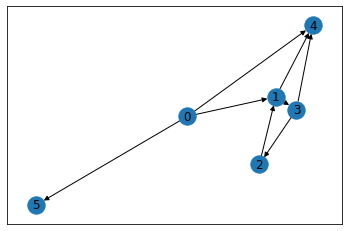

In [62]:

def dfs(node, adj={}):
    if node == None: return
    adj[node.key] = [c.key for c in node.children]
    for c in node.children:
        visited = c.key in adj
        if not visited: dfs(c, adj) 
d = {}
dfs(g, d)
print(d)
plot_graph(d)

def plot_graph_node(node):
    d = {}
    dfs(node, d)
    G = nx.DiGraph(d)
    nx.draw_networkx(G)
    plt.show()  



### Breadth first search


{0: [1, 4, 5], 1: [3, 4], 4: [], 5: [], 3: [2, 4], 2: [1]}


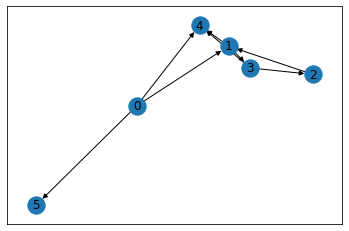

In [63]:
from stacks_queues import Queue
def bfs(node):
    adj = {}
    queue = Queue()
    queue.enqueue(node)

    while not queue.is_empty():
        curr = queue.dequeue()
        adj[curr.key] = [c.key for c in curr.children]
        
        for c in curr.children:
            visited = visited = c.key in adj
            if not visited: queue.enqueue(c)
    return adj

d = bfs(g)
print(d)
plot_graph(d)

5 {0: [1], 1: [4], 4: [0, 1, 3], 3: [1]}


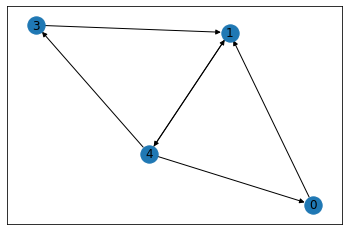

In [64]:
def create_graph(n, min=0, max=100):
    nodes = []
    for i in range(0, n):
        nodes.append(GraphNode(i))
    
    for i in range(0, n):
        node = nodes[i]
        nchildren = random.randint(1, n)
        for i in range(0, nchildren):
            rnode = random.choice(nodes)
            if rnode != node and not rnode in node.children: node.children.append(rnode)
    nodes = list(filter(lambda n: len(n.children)>0, nodes))
    return nodes[0], nodes


    print(nodes)
g2, nodes = create_graph(5)
d2 = bfs(g2)
print(len(nodes),d2)
plot_graph(d2)

## Questions

## 4.1 Route Between Nodes

Given a directed graph, design an algorithm to find out whether there is a route between two nodes.

2 1


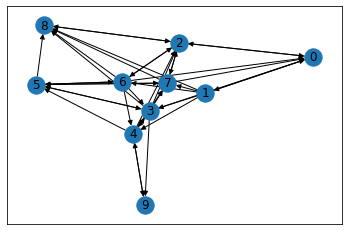

3


In [66]:

def has_route(n1, n2):
    adj = {}
    q = Queue()
    q.enqueue(n1)
    steps = 0

    while not q.is_empty():
        curr = q.dequeue()

        # check if n2 is in children
        if n2 in curr.children: return steps + 1

        # keep track of nodes in dict
        adj[curr.key] = curr
        
        # loop through children
        for c in curr.children:
            # add child to queue if not visited
            visited = c.key in adj
            if not visited: q.enqueue(c)

        steps += 1

    return steps

# test
root, nodes = create_graph(10)
node1 = random.choice(nodes)
node2 = random.choice(nodes)
print(node1.key, node2.key)
plot_graph_node(node1)
print(has_route(node1,node2))

### 4.2 Minimal Tree

Given a sorted (increasing order) array with unique integer elements, write an algorithm
to create a binary search tree with minimal height.

In [77]:
from trees_graphs import TreeNode
def min_tree(arr):

    if len(arr) == 0: return

    imid = (len(arr)-1)//2
    root = TreeNode(arr[imid])
    root.left = min_tree(arr[0:imid])
    root.right = min_tree(arr[imid+1:len(arr)])

    return root

arr = [1,2,3,4,5,6,9]
tree = min_tree(arr)
tree.display()


  _4_  
 /   \ 
 2   6 
/ \ / \
1 3 5 9


{'key': 1, 'next.key': 2}


### 4.3 List of Depths 

Given a binary tree, design an algorithm which creates a linked list of all the nodes
at each depth (e.g., if you have a tree with depth 0, you'll have 0 linked lists).

In [86]:
from linked_lists import LinkedNode
from trees_graphs import TreeNode
%reload_ext autoreload
%autoreload 2

# pre order
def list_depths(node, depth=-1, results={}):
    if node == None: return
    depth += 1

    if depth in results:
        results[depth].append(node.key)
    else:
        results[depth] = [node.key]

    list_depths(node.left, depth, results)
    list_depths(node.right, depth, results)
    return results

tree = TreeNode.random_bst(10)
tree.display()
ans = list_depths(tree)
print(ans)

       ________84_ 
      /           \
   __46_         98
  /     \          
 21_   54_____     
/   \         \    
9  39      __77    
          /        
         61_       
            \      
           63      
{0: [84], 1: [46, 98], 2: [21, 54], 3: [9, 39, 77], 4: [61], 5: [63]}


### 4.4 Check Balanced

Implement a function to check if a binary tree is balanced. For the purposes of
this question, a balanced tree is defined to be a tree such that the heights of the two subtrees of any
node never differ by more than one.

In [10]:
from linked_lists import LinkedNode
from trees_graphs import TreeNode
%reload_ext autoreload
%autoreload 2

def count_branch(node, count = [0]):
    if node == None: return
    count[0] += 1
    count_branch(node.left, count)
    count_branch(node.right, count)

    return count[0]

def check_balanced(node):
    if node == None: return

    left = count_branch(node.left, [0])
    right = count_branch(node.right, [0])

    return abs(left-right)<=1

tree = bal = TreeNode.random_bst(10)
tree.display()
print('balanced:', check_balanced(tree))

bal = TreeNode.random_balanced_bst(10)
bal.display()
print('balanced:', check_balanced(bal))


  36_________       
 /           \      
23        __63___   
         /       \  
        56_     88_ 
       /   \   /   \
      50  58  84  92
     /              
    46              
balanced: False
      __57_____   
     /         \  
    37_       84_ 
   /   \     /   \
  27  48    79  88
 /         /      
15        64      
balanced: True


### 4.5 Validate BST 

Implement a function to check if a binary tree is a binary search tree.

In [18]:
from linked_lists import LinkedNode
from trees_graphs import TreeNode
%reload_ext autoreload
%autoreload 2

rand = TreeNode.random_tree(5)
rand.display()
arr = []
TreeNode.in_order_traversal(rand, arr)
print(arr)
print()
bst = TreeNode.random_bst(5)
bst.display()
arr = []
TreeNode.in_order_traversal(bst, arr)
print(arr)


        18
       /  
    __93  
   /      
  58_     
 /   \    
65  89    
[65, 58, 89, 93, 18]

  ______98
 /        
19_       
   \      
  29___   
       \  
      63  
     /    
    58    
[19, 29, 58, 63, 98]


### 4.6 Successor

Write an algorithm to find the "next" node (i .e., in-order successor) of a given node in a
binary search tree. You may assume that each node has a link to its parent.

In [96]:
from trees_graphs import TreeNode

def successor(node):
    val = node.key
    curr = node
    lefts = 0
    
    # find top node
    while curr.parent != None and curr.parent.key > val:
        curr = curr.parent

    print('top node:', curr.key)

    # top node is succ if no right branch
    if curr.right == None: return curr

    # go down left of right branch
    curr = curr.right
    while curr.left != None and curr.left.key < val:
        curr = curr.left

    return curr

    
bst = TreeNode.random_bst(10)
try:
    print(bst.left)
except:
    print(bst.right)
bst.display()
arr = []
TreeNode.in_order_traversal(bst, arr)
print(arr)
rand = TreeNode.get_random_node(bst)
print('random:', rand.key)
succ = successor(rand)
print('successor:', succ.key if succ != None else None)


None
5____________     
             \    
  __________79___ 
 /               \
 8_________     97
           \   /  
        __63  86  
       /          
    __41_         
   /     \        
  24_   62        
     \            
    26            
[5, 8, 24, 26, 41, 62, 63, 79, 86, 97]
random: 8
top node: 79
successor: 97
